In [1]:
import os

print(os.listdir("/kaggle/input"))
import os

print(os.listdir("/kaggle/input/datasets/kanishkaabr/dataset-fed"))

['datasets']
['colloquial.csv', 'tamil_movie_reviews_test (3).csv', 'tamil_news_cleaned.csv', 'tanglish.csv', 'Shakespeare_cleaned.csv', 'codemix.csv']


In [3]:
# ==========================================================
# Module 0
# Environment Setup
# ==========================================================

print("="*70)
print("Installing Required Libraries")
print("="*70)

# Remove incompatible packages
!pip uninstall -y torchao -q

# Install compatible versions
!pip install -q \
transformers==4.49.0 \
peft==0.15.2 \
accelerate==1.4.0 \
datasets==3.3.2 \
sentencepiece \
evaluate \
sacrebleu \
rouge_score

Installing Required Libraries


In [4]:
print("="*70)
print("IMPORTANT")
print("="*70)

print("""
Installation Completed.

Please Restart the Kaggle Session.

Run
→ Restart Session

After restarting,
start from Module 0 Part C.
""")

IMPORTANT

Installation Completed.

Please Restart the Kaggle Session.

Run
→ Restart Session

After restarting,
start from Module 0 Part C.



In [5]:
# ==========================================================
# Module 0
# Verify Environment
# ==========================================================

import torch
import transformers
import peft
import accelerate
import datasets

print("="*70)
print("Environment Information")
print("="*70)

print("Torch         :", torch.__version__)
print("CUDA          :", torch.version.cuda)
print("GPU           :", torch.cuda.get_device_name(0))

print()

print("Transformers  :", transformers.__version__)
print("PEFT          :", peft.__version__)
print("Accelerate    :", accelerate.__version__)
print("Datasets      :", datasets.__version__)

print()

print("CUDA Available :", torch.cuda.is_available())

print()

x = torch.randn(2,2).cuda()

print("CUDA Test Passed ✓")

print(x)

Environment Information
Torch         : 2.10.0+cu128
CUDA          : 12.8
GPU           : Tesla T4

Transformers  : 4.49.0
PEFT          : 0.15.2
Accelerate    : 1.4.0
Datasets      : 3.3.2

CUDA Available : True

CUDA Test Passed ✓
tensor([[-1.6253,  0.2219],
        [-0.1425, -0.8943]], device='cuda:0')


In [7]:
# ==========================================================
# Module 0
# Create Project Structure
# ==========================================================

import os

PROJECT_PATH = "/kaggle/working/project"

folders = [

    "processed_dataset",

    "tokenized_dataset",

    "clients",

    "initial_peft_model",

    "client_models",

    "global_model",

    "checkpoints",

    "results",

    "plots"

]

os.makedirs(PROJECT_PATH, exist_ok=True)

for folder in folders:

    os.makedirs(

        os.path.join(

            PROJECT_PATH,

            folder

        ),

        exist_ok=True

    )

print("="*70)
print("Project Structure Created")
print("="*70)

for folder in folders:

    print(folder)

Project Structure Created
processed_dataset
tokenized_dataset
clients
initial_peft_model
client_models
global_model
checkpoints
results
plots


In [8]:
# ==========================================================
# Module 1
# Dataset Loading
# Part A
# ==========================================================

import os
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Kaggle Paths
# ----------------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets/kanishkaabr/dataset-fed"

PROJECT_PATH = "/kaggle/working/project"

TOKENIZED_PATH = os.path.join(PROJECT_PATH, "tokenized_dataset")
CLIENT_PATH = os.path.join(PROJECT_PATH, "clients")
MODEL_PATH = os.path.join(PROJECT_PATH, "client_models")
GLOBAL_MODEL_PATH = os.path.join(PROJECT_PATH, "global_model")
EVALUATION_PATH = os.path.join(PROJECT_PATH, "evaluation")
RESULT_PATH = os.path.join(PROJECT_PATH, "results")
CHECKPOINT_PATH = os.path.join(PROJECT_PATH, "checkpoints")

for folder in [
    PROJECT_PATH,
    TOKENIZED_PATH,
    CLIENT_PATH,
    MODEL_PATH,
    GLOBAL_MODEL_PATH,
    EVALUATION_PATH,
    RESULT_PATH,
    CHECKPOINT_PATH
]:
    os.makedirs(folder, exist_ok=True)

print("=" * 70)
print("Adaptive Personalized Federated Learning Framework")
print("=" * 70)

print("Dataset Path :", DATASET_PATH)
print("Project Path :", PROJECT_PATH)

Adaptive Personalized Federated Learning Framework
Dataset Path : /kaggle/input/datasets/kanishkaabr/dataset-fed
Project Path : /kaggle/working/project


In [9]:
# ==========================================================
# Module 1
# Dataset Loading
# Part B
# ==========================================================

DATASETS = {
    "Shakespeare": "Shakespeare_cleaned.csv",
    "TamilNews": "tamil_news_cleaned.csv",
    "Tanglish": "tanglish.csv",
    "CodeMix": "codemix.csv",
    "Colloquial": "colloquial.csv",
    "TamilMovie": "tamil_movie_reviews_test (3).csv"
}

loaded_datasets = {}

print("\nLoading datasets...\n")

for name, filename in DATASETS.items():

    filepath = os.path.join(DATASET_PATH, filename)

    df = pd.read_csv(filepath)

    loaded_datasets[name] = df

    print(f"{name:15s} : {df.shape}")

print("\nAll datasets loaded successfully.")


Loading datasets...

Shakespeare     : (108741, 1)
TamilNews       : (14521, 2)
Tanglish        : (11335, 2)
CodeMix         : (35139, 2)
Colloquial      : (335, 1)
TamilMovie      : (121, 3)

All datasets loaded successfully.


In [10]:
for name, df in loaded_datasets.items():
    print("\n", "="*50)
    print(name)
    print(df.columns.tolist())


Shakespeare
['PlayerLine']

TamilNews
['NewsInTamil', 'CategoryInTamil']

Tanglish
['text', 'label']

CodeMix
['text', 'label']

Colloquial
['Colloquial_Text']

TamilMovie
['ReviewId', 'ReviewInTamil', 'Rating']


In [11]:
# ==========================================================
# Module 1
# Dataset Loading
# Part C
# Standardize Text Column
# ==========================================================

COLUMN_MAP = {

    "Shakespeare": "PlayerLine",

    "TamilNews": "NewsInTamil",

    "Tanglish": "text",

    "CodeMix": "text",

    "Colloquial": "Colloquial_Text",

    "TamilMovie": "ReviewInTamil"

}

processed_datasets = {}

print("=" * 60)
print("Standardizing Datasets")
print("=" * 60)

for name, df in loaded_datasets.items():

    column = COLUMN_MAP[name]

    temp = pd.DataFrame()

    temp["text"] = df[column].astype(str)

    processed_datasets[name] = temp

    print(f"{name:15s} -> {column}")

print("\nModule 1 Part C Completed Successfully")

Standardizing Datasets
Shakespeare     -> PlayerLine
TamilNews       -> NewsInTamil
Tanglish        -> text
CodeMix         -> text
Colloquial      -> Colloquial_Text
TamilMovie      -> ReviewInTamil

Module 1 Part C Completed Successfully


In [12]:
# ==========================================================
# Module 1
# Dataset Loading
# Part D
# ==========================================================

summary = []

for name, df in processed_datasets.items():

    summary.append({

        "Dataset": name,

        "Samples": len(df),

        "Missing": df["text"].isna().sum()

    })

summary = pd.DataFrame(summary)

print("\n")
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

display(summary)

print("\nModule 1 Completed Successfully")



DATASET SUMMARY


,Dataset,Samples,Missing
0,Shakespeare,108741,0
1,TamilNews,14521,0
2,Tanglish,11335,0
3,CodeMix,35139,0
4,Colloquial,335,0
5,TamilMovie,121,0



Module 1 Completed Successfully


In [13]:
# ==========================================================
# Module 2
# Data Preprocessing
# Part A
# ==========================================================

import re

cleaned_datasets = {}

print("=" * 70)
print("Cleaning Datasets")
print("=" * 70)

for name, df in processed_datasets.items():

    before = len(df)

    # Remove missing values
    df = df.dropna()

    # Convert to string
    df["text"] = df["text"].astype(str)

    # Remove extra spaces
    df["text"] = df["text"].apply(
        lambda x: re.sub(r"\s+", " ", x).strip()
    )

    # Remove empty text
    df = df[df["text"] != ""]

    # Remove duplicates
    df = df.drop_duplicates()

    after = len(df)

    cleaned_datasets[name] = df.reset_index(drop=True)

    print(f"{name:15s} : {before} → {after}")

print("\nCleaning Completed Successfully")

Cleaning Datasets
Shakespeare     : 108741 → 105506
TamilNews       : 14521 → 10574
Tanglish        : 11335 → 11235
CodeMix         : 35139 → 34876
Colloquial      : 335 → 201
TamilMovie      : 121 → 114

Cleaning Completed Successfully


In [14]:
# ==========================================================
# Module 2
# Part B
# Save Cleaned Dataset
# ==========================================================

CLEAN_DATASET_PATH = os.path.join(
    PROJECT_PATH,
    "datasets"
)

os.makedirs(
    CLEAN_DATASET_PATH,
    exist_ok=True
)

print("=" * 70)
print("Saving Cleaned Datasets")
print("=" * 70)

for name, df in cleaned_datasets.items():

    save_path = os.path.join(
        CLEAN_DATASET_PATH,
        f"{name}.csv"
    )

    df.to_csv(
        save_path,
        index=False
    )

    print(f"{name:15s} Saved")

print("\nAll datasets saved successfully.")

# ==========================================================
# Module 2
# Part C
# Dataset Statistics
# ==========================================================

summary = []

for name, df in cleaned_datasets.items():

    lengths = df["text"].apply(len)

    summary.append({

        "Dataset": name,

        "Samples": len(df),

        "Average Length": round(lengths.mean(), 2),

        "Maximum Length": lengths.max(),

        "Minimum Length": lengths.min()

    })

summary_df = pd.DataFrame(summary)

print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

display(summary_df)

print("\nModule 2 Completed Successfully")

Saving Cleaned Datasets
Shakespeare     Saved
TamilNews       Saved
Tanglish        Saved
CodeMix         Saved
Colloquial      Saved
TamilMovie      Saved

All datasets saved successfully.
DATASET STATISTICS


,Dataset,Samples,Average Length,Maximum Length,Minimum Length
0,Shakespeare,105506,39.11,1006,1
1,TamilNews,10574,55.13,108,15
2,Tanglish,11235,56.61,513,4
3,CodeMix,34876,72.41,1124,2
4,Colloquial,201,30.01,68,3
5,TamilMovie,114,3570.44,7825,1354



Module 2 Completed Successfully


In [16]:
MODEL_NAME = "/kaggle/input/distilgpt2"

In [17]:
# ==========================================================
# Module 3
# Tokenization
# Part A
# ==========================================================

from transformers import AutoTokenizer

MODEL_NAME = "distilgpt2"

print("=" * 70)
print("Loading DistilGPT2 Tokenizer")
print("=" * 70)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# GPT2 has no PAD token
tokenizer.pad_token = tokenizer.eos_token

MAX_LENGTH = 128

print("\nTokenizer Loaded Successfully")

print("Model :", MODEL_NAME)

print("Vocabulary Size :", tokenizer.vocab_size)

print("Maximum Sequence Length :", MAX_LENGTH)

Loading DistilGPT2 Tokenizer


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizer Loaded Successfully
Model : distilgpt2
Vocabulary Size : 50257
Maximum Sequence Length : 128


In [18]:
# ==========================================================
# Module 3
# Part B
# Tokenize Dataset
# ==========================================================

from datasets import Dataset

tokenized_datasets = {}

print("=" * 70)
print("Tokenizing Datasets")
print("=" * 70)

for name, df in cleaned_datasets.items():

    print(f"\nProcessing : {name}")

    dataset = Dataset.from_pandas(df)

    def tokenize(batch):

        tokens = tokenizer(

            batch["text"],

            padding="max_length",

            truncation=True,

            max_length=MAX_LENGTH

        )

        tokens["labels"] = tokens["input_ids"].copy()

        return tokens

    tokenized = dataset.map(

        tokenize,

        batched=True,

        remove_columns=["text"]

    )

    tokenized_datasets[name] = tokenized

    print(f"Samples : {len(tokenized)}")

print("\nTokenization Completed Successfully")

Tokenizing Datasets

Processing : Shakespeare


Map:   0%|          | 0/105506 [00:00<?, ? examples/s]

Samples : 105506

Processing : TamilNews


Map:   0%|          | 0/10574 [00:00<?, ? examples/s]

Samples : 10574

Processing : Tanglish


...

Samples : 34876

Processing : Colloquial


Map:   0%|          | 0/201 [00:00<?, ? examples/s]

Samples : 201

Processing : TamilMovie


Map:   0%|          | 0/114 [00:00<?, ? examples/s]

Samples : 114

Tokenization Completed Successfully


In [19]:
# ==========================================================
# Module 3
# Part C
# Save Tokenized Dataset
# ==========================================================

TOKENIZED_PATH = os.path.join(
    PROJECT_PATH,
    "tokenized_dataset"
)

os.makedirs(
    TOKENIZED_PATH,
    exist_ok=True
)

print("=" * 70)
print("Saving Tokenized Datasets")
print("=" * 70)

for name, dataset in tokenized_datasets.items():

    save_path = os.path.join(
        TOKENIZED_PATH,
        name
    )

    dataset.save_to_disk(
        save_path
    )

    print(f"{name:15s} Saved")

print("\nAll Tokenized Datasets Saved Successfully")

# ==========================================================
# Module 3
# Part D
# Verify Dataset
# ==========================================================

print("=" * 70)
print("Tokenized Dataset Summary")
print("=" * 70)

for name, dataset in tokenized_datasets.items():

    print("\n", name)

    print(dataset)

    print(dataset[0])

Saving Tokenized Datasets


Saving the dataset (0/1 shards):   0%|          | 0/105506 [00:00<?, ? examples/s]

Shakespeare     Saved


Saving the dataset (0/1 shards):   0%|          | 0/10574 [00:00<?, ? examples/s]

TamilNews       Saved


...

CodeMix         Saved


Saving the dataset (0/1 shards):   0%|          | 0/201 [00:00<?, ? examples/s]

Colloquial      Saved


Saving the dataset (0/1 shards):   0%|          | 0/114 [00:00<?, ? examples/s]

TamilMovie      Saved

All Tokenized Datasets Saved Successfully
Tokenized Dataset Summary

 Shakespeare
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 105506
})
{'input_ids': [568, 27821, 355, 356, 389, 11, 523, 266, 272, 351, 1337, 11, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 

In [20]:
# ==========================================================
# Module 4
# Federated Client Generation
# Part A
# ==========================================================

import os

from datasets import (
    load_from_disk,
    DatasetDict
)

print("=" * 70)
print("Loading Tokenized Datasets")
print("=" * 70)

TOKENIZED_PATH = os.path.join(
    PROJECT_PATH,
    "tokenized_dataset"
)

datasets = {}

for folder in sorted(os.listdir(TOKENIZED_PATH)):

    path = os.path.join(
        TOKENIZED_PATH,
        folder
    )

    ds = load_from_disk(path)

    split = ds.train_test_split(

        test_size=0.20,

        seed=42

    )

    datasets[folder] = split

    print(f"{folder:15s} Train : {len(split['train'])}")
    print(f"{'':15s} Test  : {len(split['test'])}")
    print("-"*50)

print("\nTrain/Test Split Completed Successfully")

Loading Tokenized Datasets
CodeMix         Train : 27900
                Test  : 6976
--------------------------------------------------
Colloquial      Train : 160
                Test  : 41
--------------------------------------------------
Shakespeare     Train : 84404
                Test  : 21102
--------------------------------------------------
TamilMovie      Train : 91
                Test  : 23
--------------------------------------------------
TamilNews       Train : 8459
                Test  : 2115
--------------------------------------------------
Tanglish        Train : 8988
                Test  : 2247
--------------------------------------------------

Train/Test Split Completed Successfully


In [21]:
# ==========================================================
# Module 4
# Federated Client Generation
# Part B
# ==========================================================

import os
from datasets import concatenate_datasets

CLIENT_PATH = os.path.join(PROJECT_PATH, "clients")

os.makedirs(CLIENT_PATH, exist_ok=True)

# ----------------------------------------------------------
# Client Configuration
# ----------------------------------------------------------

client_config = {

    "Shakespeare": ["client_1", "client_2", "client_3"],

    "TamilNews": ["client_4", "client_5", "client_6", "client_7"],

    "Tanglish": ["client_8"],

    "CodeMix": ["client_9"],

    "Colloquial": ["client_10"],

    "TamilMovie": ["client_11"]

}

print("=" * 70)
print("Generating Federated Clients")
print("=" * 70)

client_summary = []

# ----------------------------------------------------------
# Create Clients
# ----------------------------------------------------------

for dataset_name, clients in client_config.items():

    train_dataset = datasets[dataset_name]["train"]

    test_dataset = datasets[dataset_name]["test"]

    total_train = len(train_dataset)

    total_test = len(test_dataset)

    num_clients = len(clients)

    train_per_client = total_train // num_clients

    test_per_client = total_test // num_clients

    print(f"\nDataset : {dataset_name}")

    for i, client in enumerate(clients):

        start_train = i * train_per_client

        end_train = (
            total_train
            if i == num_clients - 1
            else (i + 1) * train_per_client
        )

        start_test = i * test_per_client

        end_test = (
            total_test
            if i == num_clients - 1
            else (i + 1) * test_per_client
        )

        client_train = train_dataset.select(
            range(start_train, end_train)
        )

        client_test = test_dataset.select(
            range(start_test, end_test)
        )

        save_path = os.path.join(
            CLIENT_PATH,
            client
        )

        os.makedirs(save_path, exist_ok=True)

        client_train.save_to_disk(
            os.path.join(save_path, "train")
        )

        client_test.save_to_disk(
            os.path.join(save_path, "test")
        )

        client_summary.append({

            "Client": client,

            "Dataset": dataset_name,

            "Train Samples": len(client_train),

            "Test Samples": len(client_test)

        })

        print(
            f"{client:10s} "
            f"Train={len(client_train):6d} "
            f"Test={len(client_test):6d}"
        )

print("\n")
print("=" * 70)
print("11 Federated Clients Created Successfully")
print("=" * 70)

Generating Federated Clients

Dataset : Shakespeare


Saving the dataset (0/1 shards):   0%|          | 0/28134 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7034 [00:00<?, ? examples/s]

client_1   Train= 28134 Test=  7034


Saving the dataset (0/1 shards):   0%|          | 0/28134 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/41 [00:00<?, ? examples/s]

client_10  Train=   160 Test=    41

Dataset : TamilMovie


Saving the dataset (0/1 shards):   0%|          | 0/91 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23 [00:00<?, ? examples/s]

client_11  Train=    91 Test=    23


11 Federated Clients Created Successfully


In [22]:
# ==========================================================
# Module 4
# Federated Client Generation
# Part C
# ==========================================================

import os
import pandas as pd
from datasets import load_from_disk

print("=" * 70)
print("Verifying Federated Clients")
print("=" * 70)

summary = []

total_train = 0
total_test = 0

clients = sorted(
    os.listdir(CLIENT_PATH),
    key=lambda x: int(x.split("_")[1])
)

for client in clients:

    train_dataset = load_from_disk(
        os.path.join(
            CLIENT_PATH,
            client,
            "train"
        )
    )

    test_dataset = load_from_disk(
        os.path.join(
            CLIENT_PATH,
            client,
            "test"
        )
    )

    train_samples = len(train_dataset)
    test_samples = len(test_dataset)

    total_train += train_samples
    total_test += test_samples

    summary.append({

        "Client": client,

        "Train Samples": train_samples,

        "Test Samples": test_samples

    })

summary_df = pd.DataFrame(summary)

print("\n")
print("=" * 70)
print("CLIENT SUMMARY")
print("=" * 70)

display(summary_df)

print("\n")

print(f"Total Clients        : {len(summary_df)}")
print(f"Total Train Samples  : {total_train}")
print(f"Total Test Samples   : {total_test}")

# ----------------------------------------------------------
# Save Summary
# ----------------------------------------------------------

summary_path = os.path.join(
    PROJECT_PATH,
    "client_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("\nClient Summary Saved")

print(summary_path)

print("\n")
print("=" * 70)
print("Module 4 Completed Successfully")
print("=" * 70)

Verifying Federated Clients


CLIENT SUMMARY


,Client,Train Samples,Test Samples
0,client_1,28134,7034
1,client_2,28134,7034
2,client_3,28136,7034
3,client_4,2114,528
4,client_5,2114,528
5,client_6,2114,528
6,client_7,2117,531
7,client_8,8988,2247
8,client_9,27900,6976
9,client_10,160,41




Total Clients        : 11
Total Train Samples  : 130002
Total Test Samples   : 32504

Client Summary Saved
/kaggle/working/project/client_summary.csv


Module 4 Completed Successfully


In [23]:
import transformers
import peft
import accelerate

print(transformers.__version__)
print(peft.__version__)
print(accelerate.__version__)

4.49.0
0.15.2
1.4.0


In [24]:
# ==========================================================
# Module 5
# DistilGPT2 + PEFT
# Part A
# ==========================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

print("=" * 70)
print("Loading DistilGPT2")
print("=" * 70)

MODEL_NAME = "distilgpt2"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

# ----------------------------------------------------------
# Tokenizer
# ----------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Base Model
# ----------------------------------------------------------

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

base_model.to(DEVICE)

print("\nModel Loaded Successfully")

print("Vocabulary Size :", tokenizer.vocab_size)

Loading DistilGPT2
Device : cuda


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model Loaded Successfully
Vocabulary Size : 50257


In [25]:
# ==========================================================
# Module 5
# Part B
# Attach LoRA
# ==========================================================

from peft import (

    LoraConfig,

    TaskType,

    get_peft_model

)

print("=" * 70)
print("Applying LoRA")
print("=" * 70)

# ----------------------------------------------------------
# Freeze Base Model
# ----------------------------------------------------------

for param in base_model.parameters():

    param.requires_grad = False

# ----------------------------------------------------------
# LoRA Configuration
# ----------------------------------------------------------

LORA_RANK = 16

lora_config = LoraConfig(

    task_type=TaskType.CAUSAL_LM,

    r=LORA_RANK,

    lora_alpha=32,

    lora_dropout=0.1,

    bias="none",

    target_modules=[

        "c_attn",

        "c_proj"

    ]

)

model = get_peft_model(

    base_model,

    lora_config

)

model.to(DEVICE)

print("\nLoRA Attached Successfully")


# ==========================================================
# Module 5
# Part C
# Verify Model
# ==========================================================

print("=" * 70)
print("Model Summary")
print("=" * 70)

total_params = 0
trainable_params = 0

for param in model.parameters():

    total_params += param.numel()

    if param.requires_grad:

        trainable_params += param.numel()

frozen_params = total_params - trainable_params

print(f"Total Parameters     : {total_params:,}")

print(f"Trainable Parameters : {trainable_params:,}")

print(f"Frozen Parameters    : {frozen_params:,}")

print("\nTrainable Ratio :")

print(
    f"{100*trainable_params/total_params:.2f}%"
)

# ----------------------------------------------------------
# Save Initial PEFT Model
# ----------------------------------------------------------

INITIAL_MODEL_PATH = os.path.join(

    PROJECT_PATH,

    "initial_peft_model"

)

os.makedirs(

    INITIAL_MODEL_PATH,

    exist_ok=True

)

model.save_pretrained(
    INITIAL_MODEL_PATH
)

tokenizer.save_pretrained(
    INITIAL_MODEL_PATH
)

print("\nInitial PEFT Model Saved")

print(INITIAL_MODEL_PATH)

print("\n")
print("=" * 70)
print("Module 5 Completed Successfully")
print("=" * 70)

Applying LoRA

LoRA Attached Successfully
Model Summary
Total Parameters     : 82,723,584
Trainable Parameters : 811,008
Frozen Parameters    : 81,912,576

Trainable Ratio :
0.98%

Initial PEFT Model Saved
/kaggle/working/project/initial_peft_model


Module 5 Completed Successfully


In [26]:
# ==========================================================
# Module 6
# Local Federated Client Training
# Part A
# ==========================================================

import os
import json
import torch

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

from peft import (
    PeftModel
)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_PATH = os.path.join(PROJECT_PATH, "clients")

INITIAL_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "initial_peft_model"
)

CLIENT_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "client_models"
)

CHECKPOINT_PATH = os.path.join(
    PROJECT_PATH,
    "checkpoints"
)

os.makedirs(CLIENT_MODEL_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

MODEL_NAME = "distilgpt2"

NUM_EPOCHS = 5

BATCH_SIZE = 4

LEARNING_RATE = 2e-4

GRADIENT_ACCUMULATION = 2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*70)
print("Local Federated Client Training")
print("="*70)

print("Device :", DEVICE)
print("Epochs :", NUM_EPOCHS)
print("Batch Size :", BATCH_SIZE)


#loading tokenizer

print("\nLoading Tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    INITIAL_MODEL_PATH
)

tokenizer.pad_token = tokenizer.eos_token

data_collator = DataCollatorForLanguageModeling(

    tokenizer=tokenizer,

    mlm=False

)

print("Tokenizer Loaded Successfully")


#load peft model 

def load_model():

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    )

    model = PeftModel.from_pretrained(

        base_model,

        INITIAL_MODEL_PATH,

        is_trainable=True

    )

    model.to(DEVICE)

    return model


#load client dataset

def load_client_dataset(client):

    train_dataset = load_from_disk(

        os.path.join(

            CLIENT_PATH,

            client,

            "train"

        )

    )

    return train_dataset

#detect all clients

clients = sorted(

    os.listdir(CLIENT_PATH),

    key=lambda x: int(x.split("_")[1])

)

print("\nClients Found\n")

for client in clients:

    ds = load_client_dataset(client)

    print(

        f"{client:10s}",

        len(ds)

    )

print("\n")

print("="*70)
print("Module 6 Part A Completed")
print("="*70)

Local Federated Client Training
Device : cuda
Epochs : 5
Batch Size : 4

Loading Tokenizer...
Tokenizer Loaded Successfully

Clients Found

client_1   28134
client_2   28134
client_3   28136
client_4   2114
client_5   2114
client_6   2114
client_7   2117
client_8   8988
client_9   27900
client_10  160
client_11  91


Module 6 Part A Completed


In [27]:
# ==========================================================
# Module 6
# Local Federated Client Training
# Part B
# ==========================================================

def train_client(client_name):

    print("\n")
    print("="*70)
    print(f"Training {client_name}")
    print("="*70)

    train_dataset = load_client_dataset(client_name)

    print("Samples :", len(train_dataset))

    model = load_model()

    output_dir = os.path.join(
        CHECKPOINT_PATH,
        client_name
    )

    training_args = TrainingArguments(

        output_dir=output_dir,

        overwrite_output_dir=True,

        num_train_epochs=NUM_EPOCHS,

        per_device_train_batch_size=BATCH_SIZE,

        gradient_accumulation_steps=GRADIENT_ACCUMULATION,

        learning_rate=LEARNING_RATE,

        fp16=torch.cuda.is_available(),

        logging_steps=50,

        logging_strategy="steps",

        save_strategy="epoch",

        save_total_limit=1,

        report_to="none",

        remove_unused_columns=False,

        dataloader_num_workers=2

    )

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_dataset,

        data_collator=data_collator

    )

    result = trainer.train()

    print("\nTraining Completed")

    print(f"Training Loss : {result.training_loss:.4f}")

    save_path = os.path.join(
        CLIENT_MODEL_PATH,
        client_name
    )

    os.makedirs(
        save_path,
        exist_ok=True
    )

    model.save_pretrained(
        save_path
    )

    tokenizer.save_pretrained(
        save_path
    )

    metrics = {

        "client": client_name,

        "samples": len(train_dataset),

        "epochs": NUM_EPOCHS,

        "batch_size": BATCH_SIZE,

        "learning_rate": LEARNING_RATE,

        "training_loss": float(result.training_loss)

    }

    with open(

        os.path.join(

            save_path,

            "metrics.json"

        ),

        "w"

    ) as f:

        json.dump(

            metrics,

            f,

            indent=4

        )

    print("Adapter Saved")

    print(save_path)

    print("="*70)

In [28]:
train_client("client_1")



Training client_1
Samples : 28134


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCaus

Step,Training Loss
50,2.620600
100,2.469000
150,2.428400
200,2.429200
250,2.382900
300,2.358000
350,2.381300
400,2.345800
450,2.364300
500,2.365400


TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true


Training Completed
Training Loss : 2.2533
Adapter Saved
/kaggle/working/project/client_models/client_1


In [30]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [31]:
# ==========================================================
# Module 6
# Local Federated Client Training
# Part C
# Train All Clients
# ==========================================================

import os
import json

CHECKPOINT_FILE = os.path.join(
    CHECKPOINT_PATH,
    "training_checkpoint.json"
)

# ----------------------------------------------------------
# Load Completed Clients
# ----------------------------------------------------------

def load_checkpoint():

    if os.path.exists(CHECKPOINT_FILE):

        with open(CHECKPOINT_FILE, "r") as f:

            checkpoint = json.load(f)

        completed = checkpoint.get(
            "completed_clients",
            []
        )

        print("\nCheckpoint Found")

        print("Completed Clients :", len(completed))

        return completed

    return []

# ----------------------------------------------------------
# Save Completed Clients
# ----------------------------------------------------------

def save_checkpoint(completed):

    checkpoint = {

        "completed_clients": completed

    }

    with open(

        CHECKPOINT_FILE,

        "w"

    ) as f:

        json.dump(

            checkpoint,

            f,

            indent=4

        )

# ----------------------------------------------------------
# Train Remaining Clients
# ----------------------------------------------------------

def train_all_clients():

    print("\n")
    print("="*70)
    print("Starting Federated Client Training")
    print("="*70)

    completed = load_checkpoint()

    for client in clients:

        # ----------------------------------
        # Skip Completed Clients
        # ----------------------------------

        if client in completed:

            print(f"\nSkipping {client}")

            continue

        # ----------------------------------
        # Train Client
        # ----------------------------------

        train_client(client)

        completed.append(client)

        save_checkpoint(completed)

        print(f"{client} Completed")

    print("\n")
    print("="*70)
    print("All Clients Trained Successfully")
    print("="*70)

In [33]:
{
    "completed_clients": [
        "client_1"
    ]
}

{'completed_clients': ['client_1']}

In [36]:
print("CHECKPOINT_PATH :", CHECKPOINT_PATH)
print("CHECKPOINT_FILE :", CHECKPOINT_FILE)
print("Exists :", os.path.exists(CHECKPOINT_FILE))

CHECKPOINT_PATH : /kaggle/working/project/checkpoints
CHECKPOINT_FILE : /kaggle/working/project/checkpoints/training_checkpoint.json
Exists : False


In [44]:
import json
import os

checkpoint = {
    "completed_clients": [
        "client_1"
    ]
}

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

with open(CHECKPOINT_FILE, "w") as f:
    json.dump(checkpoint, f, indent=4)

print("Checkpoint Created")
print(CHECKPOINT_FILE)

Checkpoint Created
/kaggle/working/project/checkpoints/training_checkpoint.json


In [45]:
print(os.path.exists(CHECKPOINT_FILE))

print(load_checkpoint())

True

Checkpoint Found
Completed Clients : 1
['client_1']


In [46]:
train_all_clients()



Starting Federated Client Training

Checkpoint Found
Completed Clients : 1

Skipping client_1


Training client_2
Samples : 28134


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
50,2.613600
100,2.439800
150,2.431500
200,2.409700
250,2.378400
300,2.397400
350,2.369300
400,2.371200
450,2.399500
500,2.359700



Training Completed
Training Loss : 2.2566
Adapter Saved
/kaggle/working/project/client_models/client_2
client_2 Completed


Training client_3
Samples : 28136


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


...

Step,Training Loss
50,3.261700



Training Completed
Training Loss : 3.2617
Adapter Saved
/kaggle/working/project/client_models/client_10
client_10 Completed


Training client_11
Samples : 91


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss



Training Completed
Training Loss : 0.7527
Adapter Saved
/kaggle/working/project/client_models/client_11
client_11 Completed


All Clients Trained Successfully


In [47]:
# ==========================================================
# Module 7
# Adaptive Federated Aggregation
# Part A
# ==========================================================

import os
import json
import torch
from safetensors.torch import load_file, save_file

print("=" * 70)
print("Adaptive Federated Aggregation")
print("=" * 70)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

CLIENT_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "client_models"
)

GLOBAL_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "global_model"
)

os.makedirs(
    GLOBAL_MODEL_PATH,
    exist_ok=True
)

# ----------------------------------------------------------
# Detect Clients
# ----------------------------------------------------------

clients = sorted(

    os.listdir(CLIENT_MODEL_PATH),

    key=lambda x: int(x.split("_")[1])

)

print("\nClients Found\n")

for client in clients:

    print(client)

print("\nTotal Clients :", len(clients))

Adaptive Federated Aggregation

Clients Found

client_1
client_2
client_3
client_4
client_5
client_6
client_7
client_8
client_9
client_10
client_11

Total Clients : 11


In [48]:
# ==========================================================
# Module 7
# Part B
# Adaptive Client Weights
# ==========================================================

client_info = {}

total_samples = 0

for client in clients:

    metrics_path = os.path.join(

        CLIENT_MODEL_PATH,

        client,

        "metrics.json"

    )

    with open(metrics_path) as f:

        metrics = json.load(f)

    samples = metrics["samples"]

    total_samples += samples

    client_info[client] = {

        "samples": samples

    }

print("\nTotal Training Samples :", total_samples)

print("\nAggregation Weights")

print("-" * 60)

for client in clients:

    weight = (

        client_info[client]["samples"]

        / total_samples

    )

    client_info[client]["weight"] = weight

    print(

        f"{client:10s}",

        f"{weight:.6f}"

    )


Total Training Samples : 130002

Aggregation Weights
------------------------------------------------------------
client_1   0.216412
client_2   0.216412
client_3   0.216427
client_4   0.016261
client_5   0.016261
client_6   0.016261
client_7   0.016284
client_8   0.069137
client_9   0.214612
client_10  0.001231
client_11  0.000700


In [50]:
# ==========================================================
# Module 7
# Part C
# Weighted FedAvg
# ==========================================================

print("\nLoading Client Adapters...\n")

global_state = None

for idx, client in enumerate(clients):

    adapter_path = os.path.join(

        CLIENT_MODEL_PATH,

        client,

        "adapter_model.safetensors"

    )

    print("Loading :", client)

    state = load_file(adapter_path)

    weight = client_info[client]["weight"]

    if global_state is None:

        global_state = {}

        for key in state:

            global_state[key] = (

                state[key] * weight

            )

    else:

        for key in state:

            global_state[key] += (

                state[key] * weight

            )

print("\nLoRA Aggregation Completed")

# ==========================================================
# Module 7
# Part D
# Save Global Adapter
# ==========================================================

print("\nSaving Global Adapter...")

save_file(

    global_state,

    os.path.join(

        GLOBAL_MODEL_PATH,

        "adapter_model.safetensors"

    )

)

# Copy adapter configuration

import shutil

shutil.copy(

    os.path.join(

        CLIENT_MODEL_PATH,

        "client_1",

        "adapter_config.json"

    ),

    os.path.join(

        GLOBAL_MODEL_PATH,

        "adapter_config.json"

    )

)

shutil.copy(

    os.path.join(

        CLIENT_MODEL_PATH,

        "client_1",

        "tokenizer.json"

    ),

    os.path.join(

        GLOBAL_MODEL_PATH,

        "tokenizer.json"

    )

)

# ----------------------------------------------------------
# Save Aggregation Report
# ----------------------------------------------------------

report = {

    "total_clients": len(clients),

    "total_samples": total_samples,

    "client_weights": {

        c: client_info[c]["weight"]

        for c in clients

    }

}

with open(

    os.path.join(

        GLOBAL_MODEL_PATH,

        "aggregation_report.json"

    ),

    "w"

) as f:

    json.dump(

        report,

        f,

        indent=4

    )

print("Global Adapter Saved")

print("Aggregation Report Saved")

print("\n")
print("=" * 70)
print("Adaptive Federated Aggregation Completed")
print("=" * 70)


Loading Client Adapters...

Loading : client_1
Loading : client_2
Loading : client_3
Loading : client_4
Loading : client_5
Loading : client_6
Loading : client_7
Loading : client_8
Loading : client_9
Loading : client_10
Loading : client_11

LoRA Aggregation Completed

Saving Global Adapter...
Global Adapter Saved
Aggregation Report Saved


Adaptive Federated Aggregation Completed


In [51]:
# ==========================================================
# Module 8
# Global Model Evaluation
# Part A
# ==========================================================

import os
import math
import torch

from datasets import load_from_disk
from datasets import concatenate_datasets

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

from peft import PeftModel

print("="*70)
print("Loading Tokenizer")
print("="*70)

MODEL_NAME = "distilgpt2"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Tokenizer
# ----------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Load Global Model
# ----------------------------------------------------------

print("\nLoading Global Federated Model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

model = PeftModel.from_pretrained(

    base_model,

    os.path.join(
        PROJECT_PATH,
        "global_model"
    )

)

model.to(DEVICE)

model.eval()

print("Global Model Loaded Successfully")

# ----------------------------------------------------------
# Load Test Datasets
# ----------------------------------------------------------

print("\nLoading Test Datasets...")

test_datasets = []

total_samples = 0

for client in clients:

    path = os.path.join(

        CLIENT_PATH,

        client,

        "test"

    )

    ds = load_from_disk(path)

    print(

        f"{client:10s}",

        "Test Samples :", len(ds)

    )

    total_samples += len(ds)

    test_datasets.append(ds)

print("\nTotal Test Samples :", total_samples)

test_dataset = concatenate_datasets(
    test_datasets
)

print("Merged Test Dataset :", len(test_dataset))

# ----------------------------------------------------------
# Data Loader
# ----------------------------------------------------------

data_collator = DataCollatorForLanguageModeling(

    tokenizer=tokenizer,

    mlm=False

)

from torch.utils.data import DataLoader

test_loader = DataLoader(

    test_dataset,

    batch_size=8,

    shuffle=False,

    collate_fn=data_collator

)

print("\nModule 8 Part A Completed Successfully")

Loading Tokenizer

Loading Global Federated Model...
Global Model Loaded Successfully

Loading Test Datasets...
client_1   Test Samples : 7034
client_2   Test Samples : 7034
client_3   Test Samples : 7034
client_4   Test Samples : 528
client_5   Test Samples : 528
client_6   Test Samples : 528
client_7   Test Samples : 531
client_8   Test Samples : 2247
client_9   Test Samples : 6976
client_10  Test Samples : 41
client_11  Test Samples : 23

Total Test Samples : 32504
Merged Test Dataset : 32504

Module 8 Part A Completed Successfully


In [52]:
# ==========================================================
# Module 8
# Part B
# Evaluation
# ==========================================================

print("\n")
print("="*70)
print("Starting Evaluation")
print("="*70)

total_loss = 0

correct = 0

total = 0

with torch.no_grad():

    for batch in test_loader:

        batch = {

            k:v.to(DEVICE)

            for k,v in batch.items()

        }

        outputs = model(**batch)

        loss = outputs.loss

        total_loss += loss.item()

        logits = outputs.logits

        predictions = logits.argmax(dim=-1)

        labels = batch["labels"]

        mask = labels != -100

        correct += (

            (predictions == labels) & mask

        ).sum().item()

        total += mask.sum().item()

average_loss = total_loss / len(test_loader)

perplexity = math.exp(average_loss)

accuracy = (correct / total) * 100

print("\n")
print("="*70)
print("Evaluation Completed")
print("="*70)

print(f"Test Loss              : {average_loss:.4f}")

print(f"Perplexity             : {perplexity:.4f}")

print(f"Next Word Accuracy (%) : {accuracy:.2f}")

print(f"Total Tokens Evaluated : {total}")



Starting Evaluation


Evaluation Completed
Test Loss              : 4.7612
Perplexity             : 116.8817
Next Word Accuracy (%) : 2.39
Total Tokens Evaluated : 806270


In [53]:
# ==========================================================
# Module 8
# Part C
# Save Evaluation
# ==========================================================

import json

RESULT_PATH = os.path.join(

    PROJECT_PATH,

    "results"

)

os.makedirs(

    RESULT_PATH,

    exist_ok=True

)

results = {

    "Test Loss": float(average_loss),

    "Perplexity": float(perplexity),

    "Next Word Accuracy": float(accuracy),

    "Total Tokens": int(total)

}

with open(

    os.path.join(

        RESULT_PATH,

        "evaluation_results.json"

    ),

    "w"

) as f:

    json.dump(

        results,

        f,

        indent=4

    )

print("\nResults Saved Successfully")

print("="*70)
print("Module 8 Completed")
print("="*70)


Results Saved Successfully
Module 8 Completed


In [54]:
# ==========================================================
# Module 9
# Next Word Prediction
# Part A
# ==========================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import PeftModel

print("="*70)
print("Loading Global Federated Model")
print("="*70)

MODEL_NAME = "distilgpt2"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------
# Tokenizer
# ----------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

# ----------------------------------------------------------
# Base Model
# ----------------------------------------------------------

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

# ----------------------------------------------------------
# Global LoRA
# ----------------------------------------------------------

model = PeftModel.from_pretrained(

    base_model,

    os.path.join(
        PROJECT_PATH,
        "global_model"
    )

)

model.to(DEVICE)

model.eval()

print("\nGlobal Model Loaded Successfully")

Loading Global Federated Model

Global Model Loaded Successfully


In [55]:
# ==========================================================
# Module 9
# Part B
# Prediction Function
# ==========================================================

def predict_next_word(

    text,

    max_new_tokens=1

):

    inputs = tokenizer(

        text,

        return_tensors="pt"

    ).to(DEVICE)

    with torch.no_grad():

        output = model.generate(

            **inputs,

            max_new_tokens=max_new_tokens,

            do_sample=False,

            temperature=1.0,

            pad_token_id=tokenizer.eos_token_id

        )

    prediction = tokenizer.decode(

        output[0],

        skip_special_tokens=True

    )

    predicted_word = prediction[len(text):].strip()

    print("="*70)

    print("Input Sentence")

    print(text)

    print("\nPredicted Next Word")

    print(predicted_word)

    print("="*70)

    return predicted_word


# ==========================================================
# Module 9
# Part C
# Interactive Prediction
# ==========================================================

while True:

    sentence = input(

        "\nEnter Sentence (type exit to stop): "

    )

    if sentence.lower() == "exit":

        print("\nPrediction Session Closed")

        break

    predict_next_word(sentence)


Enter Sentence (type exit to stop):  the weather is


Input Sentence
the weather is

Predicted Next Word
so



Enter Sentence (type exit to stop):  I like to play


Input Sentence
I like to play

Predicted Next Word
with



Enter Sentence (type exit to stop):  நான் இன்று


Input Sentence
நான் இன்று

Predicted Next Word
�



Enter Sentence (type exit to stop):  Today நான்


Input Sentence
Today நான்

Predicted Next Word
�



Enter Sentence (type exit to stop):  exit



Prediction Session Closed


In [56]:
import torch

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for batch in test_loader:

        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)

        logits = outputs.logits

        predictions = torch.argmax(logits, dim=-1)

        labels = batch["labels"]

        mask = labels != -100

        correct += ((predictions == labels) & mask).sum().item()

        total += mask.sum().item()

accuracy = (correct / total) * 100

print(f"Correct Predictions : {correct}")
print(f"Total Tokens        : {total}")
print(f"Next Word Accuracy  : {accuracy:.2f}%")

Correct Predictions : 19251
Total Tokens        : 806270
Next Word Accuracy  : 2.39%


In [57]:
# ==========================================================
# Module 10
# Part A
# Training Summary
# ==========================================================

import os
import json
import pandas as pd

summary = []

for client in clients:

    metrics_path = os.path.join(
        CLIENT_MODEL_PATH,
        client,
        "metrics.json"
    )

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    summary.append({
        "Client": client,
        "Samples": metrics["samples"],
        "Training Loss": metrics["training_loss"]
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

summary_df.to_csv(
    os.path.join(
        PROJECT_PATH,
        "results",
        "training_summary.csv"
    ),
    index=False
)

print("\nTraining Summary Saved")

       Client  Samples  Training Loss
0    client_1    28134       2.253343
1    client_2    28134       2.256584
2    client_3    28136       2.250465
3    client_4     2114       0.509373
4    client_5     2114       0.508084
5    client_6     2114       0.510405
6    client_7     2117       0.509458
7    client_8     8988       2.563775
8    client_9    27900       1.416715
9   client_10      160       3.261653
10  client_11       91       0.752658

Training Summary Saved


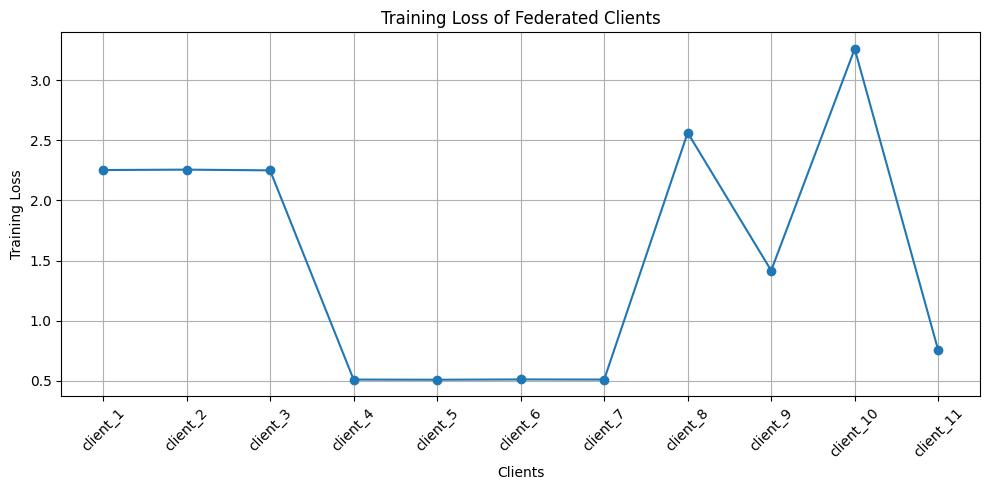

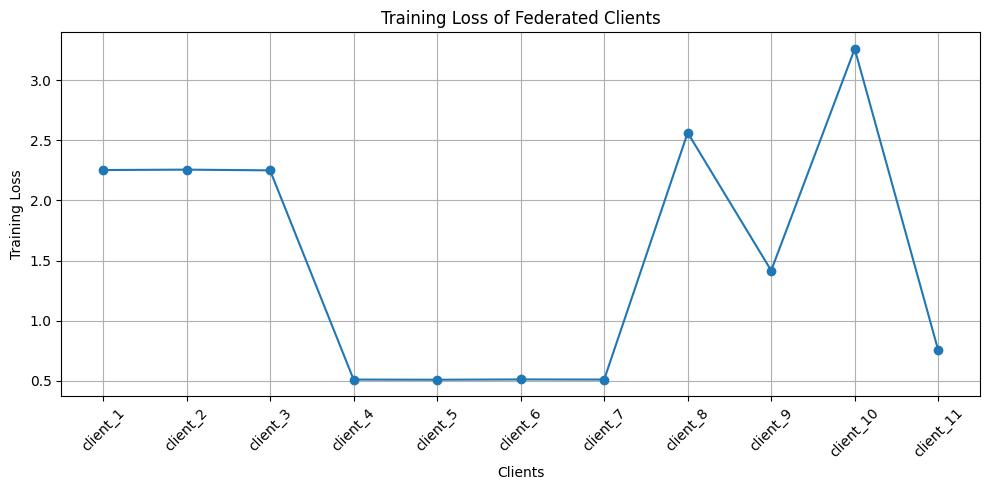

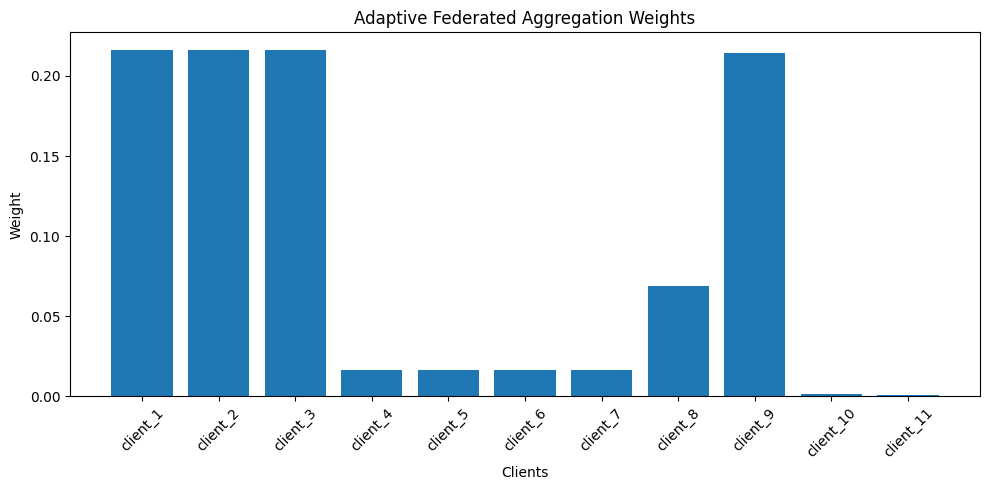

PROJECT COMPLETED SUCCESSFULLY

Final Report

Model                    : DistilGPT2
Framework                : Federated Learning
PEFT                     : LoRA
Total Clients            : 11
Training Samples         : 32504
Test Loss                : 4.761162234150715
Perplexity               : 116.88169088109346
Next Word Accuracy       : 2.3876617014151584


In [59]:
# ==========================================================
# Module 10
# Part B
# Training Loss Graph
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    summary_df["Client"],
    summary_df["Training Loss"],
    marker="o"
)

plt.title("Training Loss of Federated Clients")

plt.xlabel("Clients")

plt.ylabel("Training Loss")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_PATH,
        "results",
        "training_loss.png"
    )
)

plt.show()


# ==========================================================
# Module 10
# Part B
# Training Loss Graph
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    summary_df["Client"],
    summary_df["Training Loss"],
    marker="o"
)

plt.title("Training Loss of Federated Clients")

plt.xlabel("Clients")

plt.ylabel("Training Loss")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_PATH,
        "results",
        "training_loss.png"
    )
)

plt.show()

# ==========================================================
# Module 10
# Part C
# Client Contribution
# ==========================================================

weights = []

labels = []

for client in clients:

    labels.append(client)

    weights.append(
        client_info[client]["weight"]
    )

plt.figure(figsize=(10,5))

plt.bar(labels, weights)

plt.title("Adaptive Federated Aggregation Weights")

plt.xlabel("Clients")

plt.ylabel("Weight")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_PATH,
        "results",
        "aggregation_weights.png"
    )
)

plt.show()

# ==========================================================
# Module 10
# Part D
# Final Report
# ==========================================================

report = {

    "Model":"DistilGPT2",

    "Framework":"Federated Learning",

    "PEFT":"LoRA",

    "Total Clients":len(clients),

    "Training Samples":total_samples,

    "Test Loss":average_loss,

    "Perplexity":perplexity,

    "Next Word Accuracy":accuracy

}

with open(

    os.path.join(

        PROJECT_PATH,

        "results",

        "final_report.json"

    ),

    "w"

) as f:

    json.dump(

        report,

        f,

        indent=4

    )

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("\nFinal Report\n")

for key, value in report.items():

    print(f"{key:25s}: {value}")